In [8]:
import sys
import os

# Allow imports from app/src by adding it to sys.path, bcause this notebook is in the root directory
sys.path.append(os.path.abspath("app/src"))

In [9]:
from models.models import ContainerOptimizer

In [12]:
import pandas as pd
import time
import matplotlib.pyplot as plt
from tqdm import tqdm

# Optional: nicer plots
plt.style.use('ggplot')

In [13]:
df = pd.read_csv("app/src/data/real_data/shipoci_dataset_transformed.csv")
# Convert to list of dicts
all_pallets = df.to_dict('records')

print(f"Total pallets in dataset: {len(all_pallets)}")

Total pallets in dataset: 250901


In [14]:
sizes = [10, 20, 30, 40, 50, 100]  # adjust based the dataset size

In [ ]:
from matplotlib.pyplot import bar

results = []

for size in tqdm(sizes, desc="Evaluating algorithms"):
    pallets = all_pallets[:size]

    # --- GREEDY ---
    
    optimizer = ContainerOptimizer()
    start = time.time()
    greedy_res = optimizer.greedy_heuristic(pallets.copy())
    greedy_time = time.time() - start

    # --- MILP ---
    
    optimizer = ContainerOptimizer()
    start = time.time()
    milp_res = optimizer.milp(pallets.copy(), time_limit_seconds=60)  # keep limit small
    milp_time = time.time() - start

    # --- GA ---
    
    optimizer = ContainerOptimizer()
    start = time.time()
    ga_res = optimizer.genetic_algorithm(pallets.copy(), pop_size=30, generations=30)
    ga_time = time.time() - start

    # Store results
    results.append({
        "size": size,
        
        "greedy_profit": greedy_res["profit"],
        "greedy_time": greedy_time,
        
        "milp_profit": milp_res["profit"],
        "milp_time": milp_time,
        
        "ga_profit": ga_res["profit"],
        "ga_time": ga_time
    })
    

Evaluating algorithms: 100%|██████████| 6/6 [04:23<00:00, 43.94s/it]


In [16]:
results_df = pd.DataFrame(results)
results_df

,size,greedy_profit,greedy_time,milp_profit,milp_time,ga_profit,ga_time
0,10,12113.0,0.134627,12113.0,0.390578,12113.0,0.222611
1,20,26288.0,0.133527,26288.0,4.282958,26288.0,0.537299
2,30,33880.0,0.189059,29010.0,60.253973,33168.0,1.340520
3,40,34773.0,0.147158,13439.0,60.380053,36337.0,2.176710
4,50,34853.0,0.148661,12052.0,60.584595,38124.0,3.186492
5,100,35625.0,0.151397,5799.0,61.847360,32111.0,7.507225


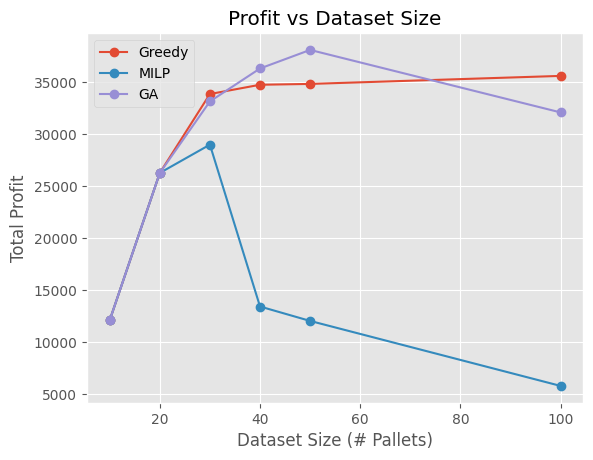

In [17]:
plt.figure()
plt.plot(results_df["size"], results_df["greedy_profit"], marker='o', label="Greedy")
plt.plot(results_df["size"], results_df["milp_profit"], marker='o', label="MILP")
plt.plot(results_df["size"], results_df["ga_profit"], marker='o', label="GA")

plt.xlabel("Dataset Size (# Pallets)")
plt.ylabel("Total Profit")
plt.title("Profit vs Dataset Size")
plt.legend()
plt.show()

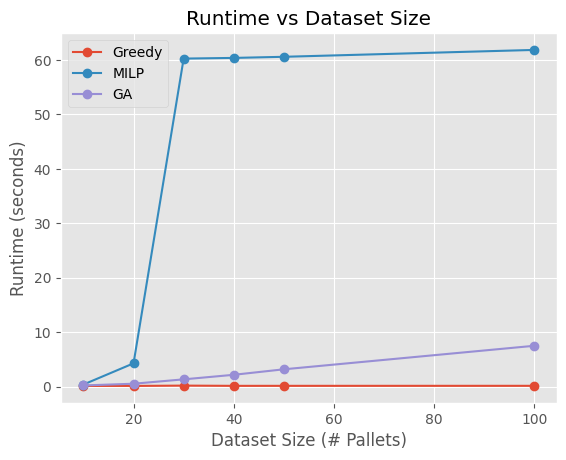

In [18]:
plt.figure()
plt.plot(results_df["size"], results_df["greedy_time"], marker='o', label="Greedy")
plt.plot(results_df["size"], results_df["milp_time"], marker='o', label="MILP")
plt.plot(results_df["size"], results_df["ga_time"], marker='o', label="GA")

plt.xlabel("Dataset Size (# Pallets)")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime vs Dataset Size")
plt.legend()
plt.show()

In [19]:
results_df.to_csv("performance_results.csv", index=False)